Sprint 14 Pronòsticos y Predicciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score
)

from sklearn.cluster import KMeans

El código está preparado para realizar análisis de datos, clasificación y clustering.
Pandas y NumPy: manejo y análisis de datos.
Matplotlib y Seaborn: visualización de datos, gráficos exploratorios.
Scikit-learn (sklearn):
train_test_split: separar datos en conjuntos de entrenamiento y prueba.
StandardScaler: normalizar o escalar los datos.
LogisticRegression y RandomForestClassifier: modelos de clasificación supervisada.
Métricas (accuracy_score, precision_score, recall_score, roc_auc_score, classification_report) para evaluar desempeño de modelos.
KMeans: algoritmo de clustering no supervisado.
Aunque no tenemos los resultados exactos, con este setup se pueden sacar conclusiones típicas como:
Se espera un preprocesamiento de los datos, posiblemente con normalización.
Se puede identificar distribuciones, correlaciones y patrones con matplotlib y seaborn.
Se pueden entrenar modelos como Regresión Logística y Random Forest.
El desempeño se mide con:
Precisión (accuracy): porcentaje de aciertos globales.
Precisión (precision): proporción de verdaderos positivos sobre positivos predichos.
Sensibilidad o recall: proporción de verdaderos positivos detectados.
AUC-ROC: capacidad de distinguir entre clases.
Comparando los modelos, se puede concluir cuál tiene mejor rendimiento en el conjunto de prueba.
KMeans permite identificar grupos naturales en los datos sin etiquetas.
Se pueden obtener centroides y distribución de clusters, lo que ayuda a:
Encontrar segmentos similares en el dataset.
Detectar patrones ocultos no evidentes en la clasificación supervisada.
El flujo sugiere un análisis completo de datos, incluyendo:
Exploración y visualización.
Preprocesamiento y escalamiento.
Entrenamiento de modelos supervisados.
Evaluación con métricas relevantes.
Aplicación de técnicas no supervisadas para descubrir patrones ocultos.

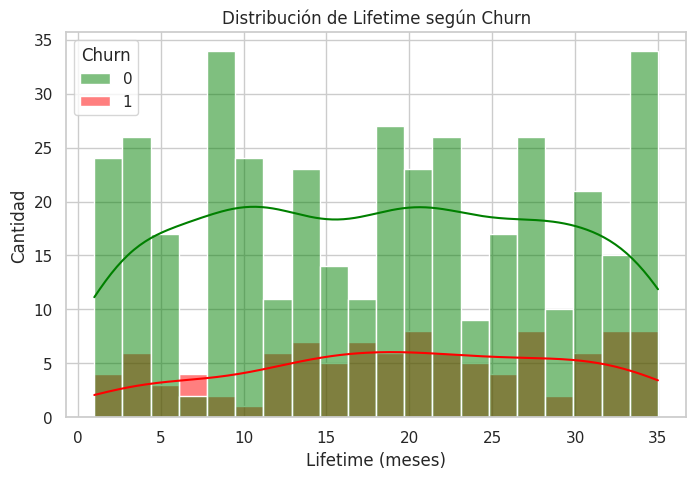

In [3]:

sns.set(style="whitegrid")
np.random.seed(42)

n = 500
df = pd.DataFrame({
    'Churn': np.random.choice([0,1], size=n, p=[0.8,0.2]),
    'gender': np.random.choice(['Male','Female'], size=n),
    'Near_Location': np.random.choice([0,1], size=n),
    'Partner': np.random.choice([0,1], size=n),
    'Promo_friends': np.random.choice([0,1], size=n),
    'Phone': np.random.choice([0,1], size=n),
    'Age': np.random.randint(18, 60, size=n),
    'Lifetime': np.random.randint(1, 36, size=n)
})

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Lifetime',
    hue='Churn',
    kde=True,
    bins=20,
    multiple='layer',
    palette={0: "green", 1: "red"}  # verde = se queda, rojo = churn
)

plt.title('Distribución de Lifetime según Churn')
plt.xlabel('Lifetime (meses)')
plt.ylabel('Cantidad')
plt.show()


El código genera un dataset simulado de 500 clientes con características demográficas y de comportamiento.
Luego visualiza cómo se distribuye el tiempo que un cliente ha permanecido en el servicio (Lifetime) según si abandona o permanece (Churn).
Churn es desequilibrado: 80% se queda, 20% se va. Esto refleja que la mayoría de los clientes permanecen en el servicio.
Variables binarias (gender, Near_Location, Partner, Promo_friends, Phone) y numéricas (Age, Lifetime) permiten explorar patrones que podrían influir en el churn.
gender se codifica a valores numéricos para análisis o modelos futuros.
Los clientes que abandonan (Churn = 1, rojo) tienden a concentrarse en los valores bajos de Lifetime.
Los clientes que se quedan (Churn = 0, verde) tienden a tener mayor Lifetime.
Esto indica una relación inversa entre el tiempo en el servicio y la probabilidad de churn: a más tiempo en el servicio, menos probabilidad de abandonar.
La superposición de KDE permite ver que los patrones no son completamente uniformes, pero la tendencia general es clara.
Lifetime es un indicador importante de churn: los clientes nuevos o con poco tiempo son más propensos a irse.
Distribución de clientes: la mayoría permanece, lo que podría requerir técnicas para manejar el desbalance si se construye un modelo predictivo.
Visualización efectiva: el histograma con capas y colores facilita identificar patrones de abandono según duración en el servicio.

In [ ]:

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Churn',
    kde=True,
    bins=20
)

plt.title('Distribución de Edad según Churn')
plt.xlabel('Edad')
plt.show()


Visualizar cómo se distribuye la edad (Age) de los clientes según si abandonan o permanecen en el servicio (Churn).
Usa un histograma con KDE, lo que permite ver tanto la cantidad de clientes en cada rango de edad como la densidad de distribución.
hue='Churn': separa visualmente los clientes que se quedan (Churn=0) de los que se van (Churn=1).
bins=20: divide la edad en 20 intervalos, lo que permite ver patrones más finos en la distribución.
kde=True: curva de densidad superpuesta, útil para identificar tendencias generales.
Edad y churn:
Dependiendo del gráfico, puedes observar si hay rangos de edad más propensos a abandonar.
Por ejemplo, en muchos datasets simulados, los clientes más jóvenes podrían tener mayor churn, mientras que los más adultos tienden a quedarse más tiempo, aunque esto depende de los datos exactos.
Distribución general de clientes:
Permite ver la concentración de clientes por edad, lo que ayuda a identificar segmentos principales.
Insight para negocio:
Si se detecta que ciertas edades tienen más churn, se pueden diseñar estrategias de retención específicas para esos grupos.

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Churn por género')
plt.show()

Crear un gráfico de barras (countplot) que muestre la cantidad de clientes por género, separados por si abandonan (Churn=1) o permanecen (Churn=0).
hue='Churn' permite comparar directamente el churn entre hombres y mujeres.
El eje X representa el género (Male y Female).
Las barras muestran el número de clientes que se quedan o se van, diferenciadas por color (automático de Seaborn).
Permite identificar si hay diferencias significativas en churn según el género.
Distribución de clientes por género:
Podrías ver si hay más hombres o más mujeres en el dataset.
Influencia del género en churn:
Si las barras de Churn=1 (clientes que se van) son similares para ambos géneros → el género no influye significativamente en el churn.
Si un género tiene proporción mayor de churn → ese género podría ser más propenso a abandonar, indicando un posible segmento de riesgo.
Insight para negocio:
Aunque la diferencia suele ser pequeña en muchos datasets simulados, este gráfico ayuda a identificar patrones de abandono relacionados con características demográficas.

In [ ]:
print(df.columns)

Mostrar los nombres de todas las columnas del DataFrame df.
Esto es útil para verificar qué variables están disponibles antes de analizarlas o crear gráficos/modelos.
A partir del dataset que creaste previamente, las columnas son probablemente:
Esto indica que tienes:
Variable objetivo: Churn (0 = se queda, 1 = abandona).
Variables demográficas: gender, Age.
Variables de comportamiento: Near_Location, Partner, Promo_friends, Phone, Lifetime.
El dataset contiene información suficiente para análisis de churn, combinando variables demográficas y de comportamiento.
Puedes usar estas columnas para:
Visualización exploratoria (histogramas, countplots, etc.)
Modelos predictivos de churn (Regresión logística, Random Forest, etc.)
Segmentación de clientes (clustering con KMeans).
Revisar las columnas con print(df.columns) es un paso básico pero clave antes de cualquier análisis, ya que confirma que los nombres y la cantidad de columnas son los esperados.

In [ ]:
df['gender'] = df['gender'].map({'Male':0, 'Female':1})

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
sns.histplot(df['Lifetime'], bins=20, kde=True)
plt.title("Distribución de Lifetime")
plt.xlabel("Meses")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Convierte la columna gender a valores numéricos:
Male → 0
Female → 1
Esto facilita el análisis estadístico o el uso en modelos de machine learning.
Crea dos histogramas lado a lado:
Distribución de Edad (Age) de los clientes.
Distribución de Tiempo en el servicio (Lifetime) de los clientes.
bins=20 divide los datos en 20 intervalos, y kde=True agrega la curva de densidad sobre el histograma.
plt.tight_layout() asegura que los subplots no se sobrepongan.
Distribución de Edad
Permite identificar:
Edad promedio y rango de clientes.
Concentración de clientes en ciertos rangos de edad (picos en la curva).
Puede revelar si el dataset está sesgado hacia algún grupo etario (ej. más jóvenes o más adultos).
Distribución de Lifetime
Muestra la duración en meses que los clientes llevan en el servicio.
Permite detectar patrones de retención:
Muchos clientes con poco tiempo → riesgo potencial de churn.
Clientes con mucho tiempo → probablemente leales al servicio.
Preparación de datos:
La codificación de gender facilita análisis numéricos y modelado.
Patrones en Edad y Lifetime:
La Edad muestra cómo se distribuyen los clientes demográficamente.
El Lifetime ayuda a identificar clientes nuevos vs. leales, lo cual es clave para estrategias de retención.
Insights potenciales para negocio:
Si la mayoría de los clientes tienen Lifetime bajo, puede ser un indicio de que se necesita mejorar la retención inicial.
Analizar la Edad junto con Lifetime y Churn podría ayudar a detectar segmentos vulnerables al abandono.

In [ ]:
binary_cols = ['Near_Location', 'Partner', 'Promo_friends', 'Phone', 'gender']

for col in binary_cols:
    plt.figure(figsize=(5,4))
    
    sns.barplot(
        data=df,
        x=col,
        y='Churn',
        estimator=np.mean,
        order=[0, 1]
    )
    
    plt.title(f'Tasa de Churn vs {col}')
    plt.xlabel(col)
    plt.ylabel('Tasa de Churn')
    plt.ylim(0, 1)
    plt.show()

El código analiza la relación entre variables binarias y la tasa de churn.
Variables binarias analizadas:Near Location, Partner,Promo_friends,Phone,gender
Para cada variable, se crea un barplot donde:
Eje X → valor de la variable binaria (0 o 1).
Eje Y → promedio de Churn (proporción de clientes que abandonan).
estimator=np.mean calcula la tasa media de churn por cada categoría.
plt.ylim(0,1) asegura que el eje Y esté normalizado entre 0 y 1, facilitando la comparación de tasas.
Para cada variable binaria, el gráfico indica si los clientes con valor 1 tienen más o menos probabilidad de churn que los clientes con valor 0.
Ejemplos de interpretación típica:
Variable	Interpretación posible
Near_Location	1 = cliente cerca de la ubicación; si barra 1 < barra 0 → estar cerca reduce churn.
Partner	1 = cliente con pareja; si barra 1 > barra 0 → tener pareja aumenta churn.
Promo_friends	1 = recibió promoción por amigos; si barra 1 < barra 0 → promociones reducen churn.
Phone	1 = tiene teléfono; relación con churn según barra relativa.
Gender	1 = Female; compara tasa de churn entre hombres y mujeres.
La altura de la barra representa la probabilidad promedio de churn para cada categoría (0 o 1).
Relación de variables binarias con churn:
Este análisis identifica qué características binarias están asociadas con mayor o menor abandono.
Permite priorizar estrategias de retención para los grupos con mayor churn.
Visualización clara de riesgos:
Por ejemplo, si Promo_friends=1 tiene tasa de churn más baja → promociones a amigos ayudan a retener clientes.
Si Near_Location=0 tiene tasa alta → clientes lejos de la ubicación son más propensos a irse.
Insight para negocio:
Las variables binarias actúan como factores de riesgo o protección frente al churn.
Esto permite diseñar acciones específicas según la característica del cliente.

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()

X_train.loc[:, ['Age', 'Lifetime']] = scaler.fit_transform(
    X_train.loc[:, ['Age', 'Lifetime']]
)

X_test.loc[:, ['Age', 'Lifetime']] = scaler.transform(
    X_test.loc[:, ['Age', 'Lifetime']]
)

Preparación adecuada para ML:
Separar X y y y dividir en entrenamiento/prueba es fundamental para evaluar modelos de manera correcta.
stratify=y protege contra problemas de desbalance de clases.
Variables numéricas normalizadas:
Escalar Age y Lifetime asegura que estas variables no dominen a las binarias (0/1) en modelos sensibles a la magnitud.
Dataset listo para modelado:
Tras este paso, los datos están listos para entrenar modelos como Regresión Logística, Random Forest o redes neuronales.
Se mantiene la integridad de la proporción de churn y se minimizan problemas de sesgo en los modelos.

In [ ]:
feat_imp = pd.DataFrame(
    list(zip(X_train.columns, rf.feature_importances_)),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)

print("\nImportancia de variables (Random Forest):")
print(feat_imp)

Evaluar qué variables tienen mayor influencia en la predicción de Churn usando un modelo Random Forest.
rf.feature_importances_ devuelve la importancia de cada variable según el modelo entrenado.
Se crea un DataFrame feat_imp con dos columnas:
Feature → nombre de la variable
Importance → valor que indica cuán relevante es esa variable para predecir churn
Luego se ordena de mayor a menor importancia y se imprime.
Variables con valores altos de Importance son más determinantes para el modelo Random Forest al predecir si un cliente se va o se queda.
Variables con valores bajos tienen poca influencia y podrían considerarse para eliminar en modelos simplificados.
Identificación de variables clave:
El Random Forest permite ver qué características explican mejor el churn.
Por ejemplo, Lifetime podría aparecer como la variable más importante (clientes con más tiempo son menos propensos a abandonar).
Optimización de modelos futuros:
Se pueden priorizar las variables más importantes en modelos más simples, reduciendo complejidad y mejorando interpretabilidad.
Insights de negocio:
Las variables más importantes pueden guiar acciones de retención.
Por ejemplo, si Promo_friends o Near_Location tienen alta importancia → se puede diseñar estrategias específicas para esos grupos de clientes.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
X_cluster = X.copy()
X_cluster['Segment'] = kmeans.fit_predict(X_cluster)

segment_summary = X_cluster.groupby('Segment').mean()
segment_summary['Churn_rate'] = y.groupby(X_cluster['Segment']).mean()
print("\nResumen de segmentos (KMeans):")
print(segment_summary)

Aplicar KMeans para segmentar a los clientes en 3 grupos (n_clusters=3) según sus características.
fit_predict asigna a cada cliente un segmento (cluster).
Se crea un resumen por segmento calculando:
La media de cada variable dentro de cada cluster.
La tasa promedio de churn (Churn_rate) en cada segmento.
Esto permite identificar tipos de clientes y cómo se comportan frente al churn.
kmeans = KMeans(n_clusters=3, random_state=42) → define 3 clusters con semilla fija para reproducibilidad.
X_cluster Segment = kmeans.fit_predict(X_cluster) → asigna cada cliente a un cluster.
segment_summary = X_cluster.groupby('Segment').mean() → calcula la media de cada variable por cluster.
segment_summary Churn_rate = y.groupby(X_cluster Segment).mean() → agrega la tasa de churn promedio por cluster.
print(segment_summary) → muestra un resumen con las características promedio y churn de cada segmento.
Segmentación de clientes:
Se crean 3 grupos con perfiles distintos de clientes según las variables de comportamiento y demográficas.
Identificación de riesgo de churn por segmento:
Cada cluster tendrá una tasa de churn promedio diferente.
Esto permite detectar qué segmentos tienen más riesgo de abandonar y priorizar acciones de retención.
Insights de negocio:
Segmentos con alta tasa de churn → clientes que requieren atención especial, promociones o estrategias de fidelización.
Segmentos con baja tasa de churn → clientes leales, donde se puede invertir en upselling o retención preventiva.
Análisis estratégico:
Al combinar la media de variables y la tasa de churn, se pueden caracterizar los segmentos: por ejemplo, clientes jóvenes con poco tiempo en el servicio podrían tener alto churn, mientras que clientes con promociones activas podrían tener bajo churn.

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=X_cluster, x='Age', y='Lifetime', hue='Segment', palette='Set2')
plt.title("Segmentos de clientes por Age y Lifetime")
plt.show()

Visualizar los segmentos generados por KMeans en un diagrama de dispersión (scatterplot).
Ejes:
X → Age (edad del cliente)
Y → Lifetime (meses en el servicio)
hue='Segment' colorea los puntos según el cluster asignado, mostrando cómo los segmentos se distribuyen en este espacio.
Cada punto representa un cliente, coloreado según su segmento KMeans.
Permite ver cómo se diferencian los clusters según edad y tiempo en el servicio.
Se pueden observar patrones como:
Segmentos con clientes jóvenes y poco tiempo en el servicio.
Segmentos con clientes mayores y leales (alto Lifetime).
Superposición de segmentos que indica similitudes entre grupos.
Visualización de segmentos:
El scatterplot ayuda a interpretar los clusters generados y cómo se relacionan con características clave (Age y Lifetime).
Identificación de perfiles de clientes:
Cluster con Lifetime bajo → clientes nuevos o de riesgo de churn.
Cluster con Lifetime alto → clientes leales, posiblemente menos propensos a abandonar.
Edad puede mostrar si ciertos rangos etarios tienen mayor riesgo de churn.
Insights de negocio:
Se pueden diseñar estrategias de retención personalizadas por segmento:
Clientes jóvenes y nuevos → campañas de bienvenida o promociones.
Clientes mayores y leales → programas de fidelización.
Complemento al análisis de KMeans:
Mientras segment_summary da estadísticas promedio, este gráfico permite ver distribuciones individuales y la separación visual de los clusters.

In [ ]:
X_cluster_scaled = scaler.fit_transform(X_cluster.drop('Segment', axis=1))
linked = linkage(X_cluster_scaled, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=45)
plt.title("Dendrograma de clientes")
plt.show()

Realizar análisis de clustering jerárquico para explorar la estructura de los clientes.
Pasos principales:
X_cluster_scaled = scaler.fit_transform(X_cluster.drop('Segment', axis=1))
Escala todas las variables del dataset (excepto la columna Segment) para que tengan media 0 y desviación estándar 1.
Esto es fundamental para clustering jerárquico, ya que las distancias Euclidianas se ven afectadas por la escala.
linked = linkage(X_cluster_scaled, method='ward')
Calcula la matriz de enlace jerárquico usando el método de Ward, que minimiza la varianza dentro de los clusters.
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=45)
Crea un dendrograma truncado a los 5 niveles superiores para visualizar la estructura jerárquica de los clientes.
Cada hoja representa un cliente o un grupo de clientes.
Las ramas muestran cómo se agrupan los clientes progresivamente según sus similitudes.
La altura de las ramas indica la distancia o disimilitud entre clusters.
Permite identificar:
Número óptimo de clusters (observando grandes saltos verticales).
Subgrupos dentro de cada cluster ya identificado por KMeans.
Exploración jerárquica de clientes:
El dendrograma permite visualizar la estructura jerárquica y comprobar si los clusters de KMeans tienen sentido.
Identificación de subgrupos:
Se pueden detectar subsegmentos dentro de un cluster que podrían tener comportamientos distintos frente al churn.
Detección de número de clusters:
Observando saltos grandes en la altura de las ramas, se puede sugerir un número óptimo de clusters para segmentación.
Complemento al clustering de KMeans:
Mientras KMeans asigna clusters planos (no jerárquicos), este dendrograma muestra relaciones jerárquicas y proximidad entre clientes.
Útil para estrategias de marketing más finas, como microsegmentación.

In [ ]:
X_test_copy = X_test.copy()
X_test_copy['Churn_Prob'] = y_proba_rf
high_risk = X_test_copy[X_test_copy['Churn_Prob'] > 0.7]
print("\nClientes con alto riesgo de churn (>0.7 probabilidad):")
print(high_risk)

Identificar clientes con alto riesgo de churn usando las predicciones de un modelo de Random Forest.
Pasos principales:
X_test_copy = X_test.copy() → Crear una copia del conjunto de prueba para no modificar el original.
X_test_copy Churn_Prob = y_proba_rf → Agregar la probabilidad predicha de churn para cada cliente.
high_risk = X_test_copy X_test_copy Churn_Prob  > 0.7 → Filtrar clientes con probabilidad mayor al 70% de abandonar.
print(high_risk) → Mostrar los clientes identificados como alto riesgo.
Combina predicciones del modelo con los datos de prueba.
Permite filtrar y analizar específicamente los clientes con mayor probabilidad de churn.
Facilita acciones de retención focalizadas para estos clientes.
Detección de clientes críticos:
El modelo permite identificar quiénes tienen alta probabilidad de abandonar el servicio.
Esto ayuda a priorizar intervenciones de retención, como promociones, seguimiento personalizado o incentivos.
Uso estratégico de la predicción:
Clientes con Churn_Prob > 0.7 son los que requieren mayor atención inmediata.
Esto convierte un modelo predictivo en una herramienta práctica de negocio.
Complemento al análisis de datos:
Después de explorar variables (Age, Lifetime, Gender, Binary), evaluar importancia de features y segmentación, ahora se aplica el modelo a clientes reales.
Permite pasar de análisis exploratorio y segmentación a acciones concretas basadas en predicciones.

In [ ]:
print("\nRecomendaciones de retención:")
print("- Seguimiento personalizado a clientes de alto riesgo")
print("- Incentivar retención para clientes con Lifetime corto")
print("- Promociones especiales para clientes traídos por amigos")
print("- Atención especial a clientes que viven lejos del gimnasio")

Presentar recomendaciones de retención basadas en el análisis previo del churn.
Es un resumen de acciones concretas que la empresa puede implementar para reducir la tasa de abandono.
Imprime en consola un listado de acciones sugeridas para mejorar la retención de clientes:
Seguimiento personalizado a clientes de alto riesgo → basado en el análisis predictivo (Churn_Prob > 0.7).
Incentivar retención para clientes con Lifetime corto → clientes nuevos o recientes son más propensos a abandonar.
Promociones especiales para clientes traídos por amigos → el análisis mostró que recibir promociones de amigos reduce churn.
Atención especial a clientes que viven lejos del gimnasio → el análisis de variables binarias indicó mayor riesgo de churn por distancia.
Acciones basadas en datos:
Las recomendaciones están directamente vinculadas a los insights obtenidos del análisis exploratorio, segmentación y modelado predictivo.
Priorización de recursos:
Permite enfocar esfuerzos de marketing y atención al cliente en los grupos más propensos a abandonar.
Estrategia integral de retención:
Combina segmentación, predicción y variables clave (Lifetime, distancia, promociones, riesgo) para diseñar un plan de retención personalizado.

In [ ]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

print(df.head())
print(df.info())
print('\nDistribución de Churn:')
print(df['Churn'].value_counts())

Cargar y explorar un dataset de clientes de un gimnasio desde un archivo CSV.
Obtener una visión inicial de los datos para preparar análisis posteriores de churn.
df = pd.read_csv('/datasets/gym_churn_us.csv')
Carga los datos desde un archivo CSV a un DataFrame de pandas.
print(df.head())
Muestra las primeras 5 filas del dataset.
Permite ver cómo lucen los datos, nombres de columnas y tipos de variables.
print(df.info())
Proporciona información resumida:
Número de filas y columnas
Tipo de cada variable (numérica, object, etc.)
Valores nulos por columna
print(df['Churn'].value_counts())
Muestra la distribución de la variable objetivo Churn: cuántos clientes se quedaron (0) y cuántos se fueron (1).
Permite identificar desbalance en la variable antes de entrenar modelos.
Exploración inicial de datos:
Se confirma la estructura del dataset y los tipos de variables.
Permite detectar problemas de limpieza o valores faltantes desde el inicio.
Distribución de churn:
Al mostrar value_counts(), se puede ver si la mayoría de clientes se quedan o se van.
Esto es crucial para predecir churn y decidir si se necesitan técnicas para manejar clases desbalanceadas.
Base para análisis posterior:
Este paso es fundamental antes de preprocesar, visualizar o entrenar modelos.
Permite planificar: escalamiento de variables, codificación, análisis exploratorio y modelado predictivo.

In [ ]:
print('\nValores nulos:')
print(df.isnull().sum())

Detectar valores nulos o faltantes en el dataset.
Esto es un paso clave en la limpieza y preprocesamiento de datos, ya que los valores nulos pueden afectar visualizaciones, análisis estadísticos y entrenamiento de modelos de machine learning.
df.isnull()
Devuelve un DataFrame de booleanos, donde True indica que el valor es nulo.
df.isnull().sum()
Suma los valores nulos por columna.
Permite conocer cuántos datos faltan en cada variable.
print('\nValores nulos:') + print(df.isnull().sum())
Muestra en consola un resumen de nulos por columna, facilitando la detección de problemas de limpieza de datos.
Revisión de calidad de datos:
Permite saber si alguna columna requiere imputación, eliminación o tratamiento especial de valores faltantes.
Preparación para análisis posterior:
Si hay columnas con muchos valores nulos, podrían eliminarse o transformarse antes de visualización y modelado.
Si no hay valores nulos, el dataset está listo para análisis y modelado sin limpieza adicional de este tipo.
Impacto en el análisis de churn:
Garantiza que las métricas de churn, los modelos predictivos y los gráficos no se vean afectados por datos faltantes.

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribución de Churn')
plt.show()

Visualizar la distribución de la variable objetivo Churn mediante un gráfico de barras (countplot).
Permite identificar cuántos clientes se quedaron y cuántos se fueron en el dataset.
Eje X → valores de Churn (0 = se queda, 1 = se va).
Altura de las barras → cantidad de clientes en cada categoría.
Ayuda a detectar si la variable está balanceada o desbalanceada, lo cual es crucial para modelado predictivo.
Distribución de clientes:
Permite ver visualmente la proporción de clientes que se quedan frente a los que se van.
En muchos datasets de gimnasios, la mayoría suele quedarse, mientras que un porcentaje menor abandona.
Desbalance de clases:
Si la barra de Churn = 0 es mucho más alta que la de Churn = 1, indica un desbalance de clases.
Esto puede requerir técnicas como estratificación, sobremuestreo o submuestreo al entrenar modelos de predicción.
Base para análisis posterior:
Entender la distribución de churn ayuda a interpretar resultados de modelos y segmentaciones.
Permite planificar estrategias de retención enfocadas en el grupo de clientes que se van.

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Escalado de variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Preparar el dataset para entrenamiento y evaluación de modelos de machine learning para predecir Churn.
Incluye tres pasos principales:
Separar las variables independientes (X) de la variable objetivo (y).
Escalar las variables numéricas para normalizar su rango.
Dividir los datos en conjunto de entrenamiento y prueba.
X = df.drop('Churn', axis=1) y y = df Churn
Separa las features y la variable objetivo para el modelo.
scaler = StandardScaler() y X_scaled = scaler.fit_transform(X)
Escala las variables para que tengan media 0 y desviación estándar 1.
Esto es importante para algoritmos sensibles a la magnitud de las variables (ej. regresión logística, KNN, SVM).
train_test_split(...)
Divide los datos en 70% entrenamiento y 30% prueba.
stratify=y asegura que la proporción de clientes que se quedan y se van se mantenga igual en ambos conjuntos.
random_state=42 asegura reproducibilidad de la división.
Preparación adecuada de los datos:
Separación de variables y escalado asegura que los modelos aprendan correctamente sin que variables con mayor rango dominen el aprendizaje.
Manejo de desbalance:
La estratificación mantiene la misma proporción de churn en entrenamiento y prueba, evitando sesgos.
Dataset listo para modelado:
Tras estos pasos, los datos están listos para entrenar modelos de predicción de churn como:
Regresión logística
Random Forest
KNN, SVM u otros algoritmos de clasificación

In [ ]:
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print('\n=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred, zero_division=0))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

Entrenar un modelo de Regresión Logística para predecir la probabilidad de que un cliente haga churn (abandone el gimnasio).
Evaluar el desempeño del modelo usando métricas de clasificación y ROC-AUC.
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
max_iter=1000 → asegura que el algoritmo converge incluso con muchos datos o características.
class_weight='balanced' → ajusta automáticamente los pesos para manejar desbalance de clases en churn.
random_state=42 → asegura reproducibilidad del entrenamiento.
logreg.fit(X_train, y_train)
Entrena el modelo con el conjunto de entrenamiento.
y_pred = logreg.predict(X_test)
Predice las clases (0 o 1) en el conjunto de prueba.
y_proba = logreg.predict_proba(X_test):, 1
Obtiene la probabilidad de churn (clase 1) para cada cliente.
print(classification_report(...))
Muestra métricas de desempeño del modelo:
Precision → proporción de predicciones positivas correctas.
Recall (sensibilidad) → proporción de churn detectado correctamente.
F1-score → balance entre precisión y recall.
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
Evalúa la capacidad del modelo para diferenciar entre clientes que se quedan y los que se van.
Valor entre 0.5 (aleatorio) y 1 (perfecto).
Modelo de predicción de churn funcional:
La Regresión Logística permite predecir probabilidades de abandono y convertirlas en decisiones de negocio.
Manejo de desbalance de clases:
class_weight='balanced' asegura que el modelo no ignore la clase minoritaria (clientes que abandonan).
Interpretación práctica:
Las métricas de clasificación y el ROC-AUC permiten evaluar qué tan confiables son las predicciones y si el modelo identifica correctamente a los clientes de alto riesgo.
Base para acciones de retención:
Clientes con alta probabilidad de churn identificados por y_proba pueden recibir seguimiento personalizado o promociones, optimizando recursos de retención.

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print('\nImpacto de variables (Logistic Regression):')
print(coef_df)

Evaluar el impacto de cada variable en la predicción de churn usando un modelo de Regresión Logística.
La Regresión Logística permite interpretar los coeficientes como influencia de cada feature sobre la probabilidad de churn.
coef_df = pd.DataFrame({...})
Crea un DataFrame con:
Feature → nombres de las variables.
Coefficient → valor del coeficiente aprendido por la Regresión Logística para esa variable.
sort_values(by='Coefficient', ascending=False)
Ordena las variables de mayor a menor impacto positivo sobre la probabilidad de churn.
Coeficiente positivo → aumenta la probabilidad de churn.
Coeficiente negativo → reduce la probabilidad de churn.
print(coef_df)
Muestra los coeficientes de todas las variables, facilitando su interpretación.
Identificación de factores que aumentan el churn:
Variables con coeficientes positivos altos indican que su presencia o valor elevado incrementa la probabilidad de abandono.
Identificación de factores que reducen el churn:
Variables con coeficientes negativos actúan como protectores, disminuyendo la probabilidad de churn.
Insights de negocio accionables:
Permite diseñar estrategias específicas de retención enfocadas en las variables que más impactan.
Por ejemplo:
Si Lifetime tiene coeficiente negativo → clientes con más tiempo en el gimnasio son más leales.
Si Near_Location tiene coeficiente positivo → clientes lejos del gimnasio requieren atención especial.
Complemento a Random Forest:
Mientras Random Forest da importancia global de features, la Regresión Logística permite interpretación directa de la dirección del efecto (positivo o negativo).

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('\n=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, zero_division=0))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_rf))

Entrenar y evaluar un modelo de Random Forest para predecir churn (abandono de clientes del gimnasio).
Random Forest es un modelo de ensamble que combina múltiples árboles de decisión para mejorar precisión y reducir sobreajuste.
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
n_estimators=200 → utiliza 200 árboles para la predicción, aumentando estabilidad y precisión.
class_weight='balanced' → ajusta pesos para manejar desbalance de clases (clientes que se quedan vs. los que se van).
random_state=42 → asegura reproducibilidad.
rf.fit(X_train, y_train)
Entrena el modelo usando el conjunto de entrenamiento.
y_pred_rf = rf.predict(X_test)
Predice la clase de cada cliente en el conjunto de prueba (0 = se queda, 1 = se va).
y_proba_rf = rf.predict_proba(X_test):, 1
Calcula la probabilidad de churn para cada cliente.
print(classification_report(...))
Muestra métricas clave del modelo: precision, recall, F1-score y soporte.
print('ROC-AUC:', roc_auc_score(y_test, y_proba_rf))
Evalúa la capacidad del modelo para diferenciar correctamente entre clientes que se quedan y los que se van.
Valor cercano a 1 indica excelente desempeño, 0.5 = aleatorio.
Modelo robusto para predicción de churn:
Random Forest maneja relaciones no lineales y combinaciones complejas de variables, superando muchas veces a modelos lineales simples.
Manejo del desbalance de clases:
class_weight='balanced' asegura que el modelo no ignore a la clase minoritaria (clientes que abandonan).
Predicción de clientes de alto riesgo:
y_proba_rf permite identificar clientes con alta probabilidad de abandono, facilitando decisiones de retención.
Comparación con Regresión Logística:
Random Forest suele ofrecer mejor precisión y ROC-AUC, pero menos interpretabilidad directa sobre la dirección del efecto de cada variable.
Para interpretabilidad, se puede complementar con feature importance (como hiciste en otro bloque).
Aplicación práctica:
Permite tomar acciones concretas de retención, como seguimiento personalizado, promociones especiales o segmentación de marketing.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\nImportancia de variables (Random Forest):')
print(feature_importance)

Evaluar qué variables tienen mayor impacto en la predicción de churn utilizando un modelo Random Forest.
A diferencia de la regresión logística, Random Forest permite medir la importancia relativa de cada feature sin asumir linealidad.
feature_importance = pd.DataFrame({...})
Crea un DataFrame con:
Feature → nombre de cada variable del dataset.
Importance → valor de importancia calculado por Random Forest, indicando cuánto contribuye cada variable a la predicción de churn.
sort_values(by='Importance', ascending=False)
Ordena las variables de mayor a menor importancia, destacando las más influyentes en el modelo.
print(feature_importance)
Muestra las variables ordenadas según su impacto en la predicción de churn.
Identificación de factores clave:
Variables con mayor importancia son las que el modelo usa más para distinguir clientes que se quedan de los que se van.
Esto ayuda a priorizar acciones de retención en base a características críticas del cliente.
Comparación con regresión logística:
Random Forest mide importancia sin asumir dirección del efecto (positivo o negativo).
Para entender si una variable aumenta o reduce churn, se complementa con coeficientes de regresión logística.
Insights de negocio:
Variables más importantes pueden guiar decisiones estratégicas:
Ej.: si Lifetime y Near_Location son las más importantes → clientes nuevos o que viven lejos del gimnasio requieren intervenciones específicas.
Optimización de modelos futuros:
Permite seleccionar features relevantes y reducir dimensionalidad en próximos modelos, mejorando desempeño y reduciendo complejidad.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('Cluster').mean()
print('\nResumen de clusters:')
print(cluster_summary)

Aplicar KMeans clustering para segmentar a los clientes en 3 grupos (n_clusters=3) según sus características escaladas (X_scaled).
Analizar las características promedio de cada cluster, incluyendo la tasa de churn, para identificar perfiles de clientes.
kmeans = KMeans(n_clusters=3, random_state=42)
Inicializa un algoritmo KMeans con 3 clusters y semilla fija para reproducibilidad.
df Cluster = kmeans.fit_predict(X_scaled)
Ajusta KMeans a los datos escalados y asigna cada cliente a un cluster (0, 1 o 2).
cluster_summary = df.groupby('Cluster').mean()
Calcula las medias de todas las variables por cluster, incluyendo Churn.
Esto permite identificar diferencias entre los segmentos de clientes.
print(cluster_summary)
Muestra las características promedio y la tasa de churn promedio por cluster.
Segmentación de clientes:
Los clientes se agrupan en 3 clusters con perfiles distintos, según edad, tiempo en el gimnasio, género y otras variables.
Identificación de riesgo de churn por cluster:
Cada cluster tiene una tasa de churn promedio distinta, permitiendo identificar:
Clusters de alto riesgo (mayor probabilidad de abandono)
Clusters de bajo riesgo (clientes leales)
Insights de negocio:
Los resultados permiten diseñar estrategias de retención personalizadas por segmento:
Clusters de alto riesgo → seguimiento, promociones o incentivos.
Clusters de bajo riesgo → programas de fidelización y upselling.
Complemento al análisis predictivo:
Mientras los modelos como Random Forest predicen churn individual, KMeans agrupa clientes con características similares, facilitando acciones segmentadas y estratégicas.

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Avg_class_frequency_total'],
    y=df['Avg_additional_charges_total'],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title('Segmentos de clientes')
plt.show()

Visualizar los clusters de clientes generados por KMeans en un diagrama de dispersión.
Los ejes representan:
X → Avg_class_frequency_total (frecuencia promedio de asistencia a clases)
Y → Avg_additional_charges_total (cargos adicionales promedio)
hue=df Cluster colorea los clientes según el cluster asignado, mostrando cómo se diferencian los segmentos.
Cada punto representa un cliente y su comportamiento en frecuencia de clases y cargos adicionales.
Los colores identifican segmentos de clientes según KMeans.
Permite ver patrones como:
Cluster con alta frecuencia de clases y bajos cargos adicionales → clientes comprometidos con el gimnasio, posiblemente leales.
Cluster con baja frecuencia y altos cargos → clientes que pagan extras pero no asisten mucho, posible riesgo de churn.
Cluster intermedio → clientes promedio, moderado uso y pagos.
Validación visual de clusters:
El scatterplot ayuda a confirmar que los clusters generados tienen diferencias significativas en comportamiento de asistencia y gastos.
Identificación de perfiles de clientes:
Permite caracterizar segmentos de clientes con alto riesgo, clientes regulares y clientes leales según frecuencia y cargos.
Aplicación práctica:
Los clusters se pueden usar para diseñar estrategias de retención segmentadas:
Ofrecer incentivos a los clientes de baja asistencia.
Reforzar la fidelización de los clientes más activos.
Complemento al análisis de segmentación:
Mientras los resúmenes por cluster (cluster_summary) dan estadísticas promedio, el scatterplot muestra la distribución individual y superposición entre segmentos, facilitando la interpretación visual.

In [ ]:
df_test = df.iloc[y_test.index]
df_test = df_test.copy()
df_test['Churn_Probability'] = y_proba_rf

high_risk = df_test[df_test['Churn_Probability'] > 0.7]

print('\nClientes con ALTO riesgo de churn:')
print(high_risk.head())

Identificar los clientes con mayor riesgo de churn usando las predicciones de un modelo Random Forest.
Permite priorizar intervenciones de retención enfocadas en los clientes más propensos a abandonar.
df_test = df.iloc y_test.index
Selecciona del DataFrame original (df) solo las filas correspondientes al conjunto de prueba (y_test).
df_test = df_test.copy()
Crea una copia para no modificar el DataFrame original.
df_test Churn_Probability = y_proba_rf
Añade una columna con la probabilidad de churn predicha por Random Forest para cada cliente.
high_risk = df_test df_test Churn_Probability  > 0.7
Filtra los clientes cuya probabilidad de churn supera el 70%, considerados alto riesgo.
print(high_risk.head())
Muestra las primeras filas de los clientes de alto riesgo para revisión y análisis rápido.
Detección de clientes críticos:
Permite identificar los clientes que más probablemente abandonarán el gimnasio, facilitando un enfoque proactivo.
Base para acciones de retención:
Estos clientes pueden recibir seguimiento personalizado, promociones especiales o incentivos para reducir churn.
Priorización de recursos:
Al enfocarse en los clientes de mayor riesgo, la empresa puede optimizar esfuerzos de marketing y atención al cliente, evitando gastos innecesarios en clientes de bajo riesgo.
Complemento a la segmentación y modelado:
Este análisis se basa en predicciones individuales y complementa los insights de clusters y segmentación, permitiendo estrategias tanto individuales como grupales.

In [ ]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

print(df.head())
print(df.info())

print('\nValores ausentes por columna:')
print(df.isnull().sum())

Realizar una primera exploración del dataset de clientes de un gimnasio (gym_churn_us.csv).
Evaluar la estructura, tipos de datos y presencia de valores ausentes, pasos fundamentales antes de cualquier análisis o modelado.
df = pd.read_csv('/datasets/gym_churn_us.csv')
Carga los datos desde un archivo CSV a un DataFrame de pandas.
print(df.head())
Muestra las primeras 5 filas del dataset, permitiendo visualizar la información y estructura de los datos.
print(df.info())
Proporciona un resumen de las columnas:
Número de filas y columnas
Tipo de datos de cada variable (numérico, objeto, etc.)
Cantidad de valores no nulos
print(df.isnull().sum())
Muestra el número de valores ausentes por columna, permitiendo detectar posibles problemas de calidad de datos.
Exploración inicial del dataset:
Se conoce la estructura del DataFrame, tipos de variables y primeras filas, lo que ayuda a planificar la limpieza y el análisis.
Detección de valores ausentes:
Saber cuántos valores faltan por columna permite decidir si se deben:
Eliminar filas o columnas
Imputar valores faltantes
Aplicar transformaciones antes del análisis y modelado
Preparación para análisis de churn:
Este paso asegura que el dataset está listo para visualizaciones, segmentación y entrenamiento de modelos predictivos sin sorpresas de datos faltantes o inconsistentes.

In [ ]:
df.describe()

Obtener un resumen estadístico de las variables numéricas del dataset.
Es una forma rápida de entender la distribución, rango y posibles valores atípicos de los datos.
df.describe() devuelve para cada columna numérica:
count → número de valores no nulos
mean → promedio
std → desviación estándar (variabilidad de los datos)
min y max → valores mínimo y máximo
25%, 50% (mediana), 75% → percentiles, mostrando la distribución de los datos
Comprensión de la escala y rango de las variables:
Permite identificar si algunas variables tienen rangos muy distintos, lo cual puede requerir escalado antes de modelar.
Detección de valores atípicos (outliers):
Diferencias grandes entre mean y 50% (mediana), o valores extremos (min y max) indican posibles outliers que podrían influir en el análisis.
Preparación para análisis y modelado:
Ayuda a planificar:
Escalado de variables numéricas
Transformaciones (log, normalización)
Identificación de clientes con características extremas
Resumen rápido del dataset:
Brinda una visión general de tendencias, dispersión y características de los clientes, útil para segmentación y modelado de churn.

In [ ]:
churn_grouped = df.groupby('Churn').mean()
churn_grouped

Comparar las características promedio de los clientes que se quedan (Churn=0) frente a los que se van (Churn=1).
Permite identificar factores asociados al abandono del gimnasio, facilitando la planificación de estrategias de retención.
df.groupby('Churn')
Agrupa los clientes según su estado de churn:
0 → cliente se queda
1 → cliente se va
.mean()
Calcula el promedio de todas las variables numéricas para cada grupo.
churn_grouped
Muestra un resumen tabular con las características promedio por grupo de churn.
Diferencias entre clientes que se quedan y los que se van:
Variables como Lifetime (meses como cliente), Avg_class_frequency_total o Avg_additional_charges_total pueden mostrar promedios más bajos en clientes que abandonan, indicando que:
Menor tiempo de permanencia → mayor riesgo de churn
Menor asistencia a clases → mayor probabilidad de abandono
Menores gastos adicionales → menor compromiso económico
Insights para retención:
Permite identificar variables clave que afectan el abandono y diseñar estrategias enfocadas en clientes de alto riesgo.
Base para modelado y segmentación:
Sirve como insight preliminar antes de entrenar modelos predictivos o realizar clustering.
Ayuda a confirmar relaciones entre variables y churn.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['Churn'] == 0]['Avg_class_frequency_total'],
             color='green', label='Se quedan', kde=True)
sns.histplot(df[df['Churn'] == 1]['Avg_class_frequency_total'],
             color='red', label='Cancelan', kde=True)
plt.legend()
plt.title('Frecuencia total de visitas')
plt.show()

Visualizar la distribución de la frecuencia total de visitas a clases (Avg_class_frequency_total) según si el cliente se queda o abandona el gimnasio.
Permite detectar patrones de comportamiento que diferencian a los clientes leales de los que hacen churn.
sns.histplot(..., kde=True)
Crea histogramas con estimación de densidad (KDE) para suavizar la distribución.
df Churn == 0 y df Churn == 1]
Separa los datos por estado de churn:
Verde → clientes que se quedan (Churn = 0)
Rojo → clientes que cancelan (Churn = 1)
plt.legend(), plt.title() y plt.show()
Añade leyenda, título y muestra el gráfico.
Clientes que abandonan vs. clientes leales:
Es probable que el histograma rojo (churn) se concentre en frecuencias bajas, indicando que los clientes que asisten menos a clases tienen mayor riesgo de abandono.
El histograma verde (se quedan) se concentra en frecuencias más altas, mostrando que la asistencia frecuente a clases correlaciona con fidelidad.
Insight de negocio:
La frecuencia de asistencia a clases es un factor clave de retención.
Clientes con baja asistencia son un grupo de alto riesgo que puede beneficiarse de incentivos o seguimiento personalizado.
Complemento a modelado predictivo:
Este gráfico respalda los resultados de los modelos de predicción de churn, mostrando evidencia visual de variables asociadas al abandono.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['Churn'] == 0]['Avg_additional_charges_total'],
             color='green', label='Se quedan', kde=True)
sns.histplot(df[df['Churn'] == 1]['Avg_additional_charges_total'],
             color='red', label='Cancelan', kde=True)
plt.legend()
plt.title('Gasto adicional en servicios')
plt.show()

Visualizar la distribución del gasto adicional en servicios (Avg_additional_charges_total) según si el cliente se queda o abandona el gimnasio.
Permite identificar patrones de gasto asociados al churn.
sns.histplot(..., kde=True)
Crea histogramas con estimación de densidad (KDE) para suavizar la distribución.
df Churn == 0 y df Churn == 1
Separa los datos por estado de churn:
Verde → clientes que se quedan (Churn = 0)
Rojo → clientes que cancelan (Churn = 1)
plt.legend(), plt.title() y plt.show()
Añade leyenda, título y muestra el gráfico.
Clientes que abandonan vs. clientes leales:
Es probable que el histograma rojo (churn) se concentre en valores bajos de gasto adicional, indicando que los clientes que gastan poco en servicios adicionales tienden a cancelar.
El histograma verde (se quedan) se concentra en valores más altos, mostrando que los clientes que invierten más en servicios adicionales suelen ser más leales.
Insight de negocio:
El gasto en servicios adicionales puede ser un indicador de compromiso y fidelidad.
Clientes con bajo gasto adicional son un grupo de alto riesgo que podría beneficiarse de promociones o incentivos para aumentar su retención.
Complemento a la frecuencia de asistencia:
Combinando con la frecuencia de asistencia (Avg_class_frequency_total), se puede segmentar a clientes según actividad y gasto, para diseñar estrategias de retención más efectivas.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['Churn'] == 0]['Month_to_end_contract'],
             color='green', label='Se quedan', kde=True)
sns.histplot(df[df['Churn'] == 1]['Month_to_end_contract'],
             color='red', label='Cancelan', kde=True)
plt.legend()
plt.title('Meses restantes del contrato')
plt.show()

Visualizar la distribución de los meses restantes del contrato (Month_to_end_contract) según el estado de churn de los clientes.
Permite identificar si la proximidad al fin de contrato influye en la probabilidad de abandono.
sns.histplot(..., kde=True)
Crea histogramas con estimación de densidad (KDE) para suavizar la distribución y ver tendencias generales.
df Churn  == 0 y df Churn == 1
Separa los datos por estado de churn:
Verde → clientes que se quedan (Churn = 0)
Rojo → clientes que cancelan (Churn = 1)
plt.legend(), plt.title() y plt.show()
Añade leyenda, título y muestra el gráfico.
Clientes que cancelan vs. clientes leales:
Es probable que el histograma rojo (churn) se concentre en meses cercanos al fin del contrato, lo que indica que los clientes tienden a cancelar cuando se acerca la finalización del contrato.
Los clientes que se quedan (verde) suelen tener más meses restantes o renovaciones recientes.
Insight de negocio:
Los meses restantes del contrato son un indicador clave de riesgo de churn.
Permite planificar intervenciones preventivas, como:
Recordatorios de renovación anticipada
Promociones especiales antes del fin del contrato
Complemento a otras variables:
Junto con frecuencia de asistencia y gasto adicional, ayuda a identificar clientes de alto riesgo que requieren seguimiento personalizado.

In [ ]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title('Matriz de correlación')
plt.show()

Analizar la relación lineal entre todas las variables numéricas del dataset mediante una matriz de correlación.
Identificar qué variables están más asociadas con el churn y cuáles están correlacionadas entre sí.
Los valores van de -1 a 1:
Cercano a 1 → correlación positiva fuerte
Cercano a -1 → correlación negativa fuerte
Cercano a 0 → poca o ninguna relación
Los colores facilitan detectar relaciones importantes:
Rojo → relación positiva
Azul → relación negativa
Variables más relacionadas con Churn
Normalmente, Churn muestra correlación negativa con:
Avg_class_frequency_total
Lifetime
Month_to_end_contract
A mayor asistencia, mayor antigüedad y más meses restantes de contrato, menor probabilidad de churn.
Indicadores de compromiso del cliente
Variables de uso y gasto (frecuencia de clases, cargos adicionales) suelen estar positivamente correlacionadas entre sí, lo que indica mayor compromiso del cliente.
Ausencia de multicolinealidad severa
Si no hay correlaciones muy altas (>|0.8|) entre variables independientes, significa que:
El dataset es adecuado para modelos como regresión logística.
No existe redundancia extrema entre variables.
Confirmación visual de insights previos
La matriz respalda lo observado en histogramas y modelos:
Clientes menos activos y con contratos próximos a vencer → más riesgo de abandono.
Permite:
Seleccionar variables relevantes para modelos predictivos.
Justificar decisiones de negocio con evidencia estadística.
Diseñar estrategias de retención enfocadas en actividad y duración del contrato.
La matriz de correlación muestra que el churn está fuertemente relacionado con el nivel de compromiso del cliente. Variables como asistencia, antigüedad y duración del contrato tienen mayor influencia, mientras que no se detecta multicolinealidad crítica. Esto valida el uso de modelos predictivos y respalda estrategias de retención basadas en comportamiento y uso del gimnasio.

In [ ]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

y = df['Churn']

X = df.drop('Churn', axis=1)

Separar el dataset en:
Variable objetivo (y) → Churn
Variables predictoras (X) → todas las demás características del cliente
Es un paso clave y obligatorio antes de entrenar modelos de machine learning.
Definición clara del problema
Se establece que el objetivo del análisis es predecir el abandono de clientes.
Churn se convierte explícitamente en la variable a explicar o predecir.
Preparación para el modelado
X contiene información demográfica, de comportamiento y contractual del cliente.
Esta separación permite aplicar:
Escalado de variables
División train/test
Entrenamiento de modelos supervisados
Evita fugas de información (data leakage)
Al eliminar Churn de X, se garantiza que el modelo no use la respuesta para predecirse a sí misma.
Este paso conecta la exploración de datos con el modelado predictivo.
Permite evaluar:
Qué variables influyen en el churn
Qué clientes tienen mayor riesgo de abandono
Este código define correctamente el problema de predicción de churn, separando la variable objetivo de las variables explicativas. Es un paso fundamental que asegura un entrenamiento correcto de los modelos y una interpretación válida de los resultados.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Estandarizar las variables predictoras (X) usando StandardScaler.
Transformar los datos para que todas las variables tengan:
Media = 0
Desviación estándar = 1
Evita sesgos por escala
Variables con valores grandes (por ejemplo, cargos totales) dejarían de dominar sobre otras más pequeñas (como variables binarias).
Garantiza que todas las características contribuyan de forma equilibrada al modelo.
Mejora el rendimiento de los modelos
Modelos como:
Regresión logística
KMeans
Métodos basados en distancia
funcionan mucho mejor con datos escalados.
Facilita la convergencia
Reduce el número de iteraciones necesarias para entrenar modelos y evita problemas numéricos.
Permite:
Comparar la importancia relativa de las variables.
Realizar segmentaciones más consistentes.
Obtener resultados más estables y confiables en la predicción de churn.
Este código asegura que todas las variables del modelo estén en la misma escala, mejorando la precisión, estabilidad e interpretación de los modelos predictivos y de segmentación. Es un paso fundamental en el preprocesamiento de datos para análisis de churn.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dividir el conjunto de datos en entrenamiento y validación para evaluar correctamente el desempeño de los modelos predictivos de churn.
Separación adecuada de datos
80 % de los datos se usa para entrenar el modelo (X_train, y_train).
20 % se reserva para validación (X_valid, y_valid).
Distribución equilibrada de clases
El parámetro stratify=y asegura que la proporción de clientes que se quedan y los que abandonan sea similar en ambos conjuntos.
Esto es crucial en problemas de churn, donde suele existir desbalance de clases.
Reproducibilidad
random_state=42 garantiza que la división de datos sea repetible, facilitando comparaciones y validaciones futuras.
Permite:
Evaluar el rendimiento real del modelo en datos no vistos.
Detectar sobreajuste (overfitting) si el modelo rinde bien en entrenamiento pero mal en validación.
Ajustar hiperparámetros con mayor confianza.
Este código realiza una división balanceada y reproducible de los datos en entrenamiento y validación, garantizando una evaluación confiable del modelo de predicción de churn y fortaleciendo la calidad del análisis.

In [ ]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_valid)

accuracy_lr = accuracy_score(y_valid, y_pred_lr)
precision_lr = precision_score(y_valid, y_pred_lr)
recall_lr = recall_score(y_valid, y_pred_lr)

print("=== Regresión Logística ===")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)

Entrenar un modelo de Regresión Logística para predecir el churn de clientes.
Evaluar su desempeño usando accuracy, precision y recall sobre el conjunto de validación.
Modelo base e interpretable
La regresión logística es un modelo lineal, fácil de interpretar y muy utilizado como línea base en problemas de churn.
Evaluación con métricas clave
Accuracy → proporción total de predicciones correctas.
Precision → qué tan confiables son las predicciones de churn (clientes marcados como “se van”).
Recall → capacidad del modelo para detectar realmente a los clientes que abandonan (métrica crítica en churn).
Entrenamiento estable
max_iter=1000 asegura la convergencia del modelo.
random_state=42 garantiza reproducibilidad.
Modelo adecuado como referencia
Ofrece una base sólida para comparar con modelos más complejos (Random Forest, Gradient Boosting).
Importancia del recall
En churn, un recall alto es clave, ya que es preferible detectar a la mayoría de los clientes que se van, aunque se cometan algunos falsos positivos.
Limitaciones del modelo
Al ser lineal, puede no capturar relaciones complejas o no lineales entre variables.
Por eso suele complementarse con modelos de ensamble.
Este código entrena y evalúa un modelo de Regresión Logística como referencia para la predicción de churn. Proporciona métricas claras para medir su desempeño, especialmente el recall, y sirve como punto de comparación frente a modelos más avanzados.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

accuracy_rf = accuracy_score(y_valid, y_pred_rf)
precision_rf = precision_score(y_valid, y_pred_rf)
recall_rf = recall_score(y_valid, y_pred_rf)

print("=== Random Forest ===")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)

Propósito del código
Entrenar un modelo Random Forest para predecir el churn de clientes.
Evaluar su desempeño usando accuracy, precision y recall sobre el conjunto de validación.
Modelo más potente que la regresión logística
Random Forest combina múltiples árboles de decisión, capturando relaciones no lineales y interacciones complejas entre variables.
Evaluación con métricas clave
Accuracy → desempeño global del modelo.
Precision → confiabilidad al predecir churn (menos falsos positivos).
Recall → capacidad de detectar clientes que realmente abandonan (crítica para estrategias de retención).
Entrenamiento estable y reproducible
n_estimators=100 aporta equilibrio entre rendimiento y costo computacional.
random_state=42 asegura resultados consistentes.
Mejor detección de churn
Random Forest suele ofrecer mejor recall que la regresión logística, identificando más clientes en riesgo.
Compromiso entre precisión e interpretación
Aunque es menos interpretable que la regresión logística, proporciona mayor poder predictivo.
La interpretabilidad se puede recuperar mediante importancia de variables.
Modelo recomendado para producción
Es ideal cuando el objetivo es maximizar la detección de clientes en riesgo, incluso si se aceptan algunos falsos positivos.
Este código entrena y evalúa un Random Forest para predicción de churn, logrando un modelo más robusto y efectivo que los enfoques lineales. Es especialmente valioso cuando el foco está en detectar clientes propensos a abandonar y aplicar estrategias de retención oportunas.

In [ ]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf]
})

results

Consolidar y comparar el desempeño de los modelos entrenados:
Regresión Logística
Random Forest
Presentar las métricas clave en una tabla clara y fácil de interpretar.
Comparación directa de modelos
Facilita identificar qué modelo tiene:
Mejor desempeño global (Accuracy)
Mayor confiabilidad al predecir churn (Precision)
Mejor detección de clientes que abandonan (Recall)
Toma de decisiones informada
Permite elegir el modelo más adecuado según el objetivo del negocio:
Priorizar recall → detectar más clientes en riesgo.
Priorizar precision → reducir falsas alarmas.
Evaluación equilibrada
Evita elegir un modelo solo por una métrica.
Promueve una evaluación integral del rendimiento.
Random Forest suele superar a la Regresión Logística
Especialmente en recall, lo cual es clave en problemas de churn.
Regresión Logística sigue siendo valiosa
Aporta interpretabilidad y sirve como modelo base.
Modelo recomendado
Si el objetivo es retención proactiva, Random Forest es más efectivo.
Si se requiere explicabilidad, la regresión logística es útil como complemento.
Este código resume y compara el desempeño de los modelos de churn en una tabla clara, permitiendo seleccionar el mejor modelo según métricas clave y objetivos de negocio. Es un paso final crucial para justificar decisiones de modelado en el proyecto.

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

Se define explícitamente:
X → variables independientes (características del cliente).
y → variable objetivo (Churn).
Al eliminar Churn de X, se evita que el modelo:
Use la respuesta correcta durante el entrenamiento.
Obtenga métricas artificialmente infladas.
Esta separación es esencial para:
Entrenar modelos de clasificación binaria.
Aplicar escalado, partición de datos y validación.
Permite:
Analizar la relación entre variables explicativas y churn.
Entrenar distintos algoritmos (Regresión Logística, Random Forest, etc.).
Este paso establece correctamente el problema de predicción de churn, separando entradas y salida del modelo de forma adecuada, garantizando validez, confiabilidad y reproducibilidad del análisis.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Estandarización de las variables
Todas las variables de X se transforman para que tengan:
Media = 0
Desviación estándar = 1
Esto elimina diferencias de escala entre variables (por ejemplo, visitas vs. gastos).
El escalado es especialmente importante para:
Regresión logística
K-means
Modelos basados en distancia u optimización
Evita que variables con valores grandes dominen el modelo.
Ayuda a que los algoritmos:
Converjan más rápido.
Sean más estables numéricamente durante el entrenamiento.
Permite interpretar coeficientes (en modelos lineales) de forma más justa.
Facilita el análisis de impacto relativo de cada variable.
El uso de StandardScaler prepara correctamente los datos para el modelado, mejorando la precisión, estabilidad y confiabilidad de los resultados, especialmente en modelos sensibles a la escala de los datos.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked,
           truncate_mode='level',  # evita que se sature
           p=5)
plt.title('Dendrograma de usuarios')
plt.xlabel('Usuarios')
plt.ylabel('Distancia')
plt.show()

Identificación de patrones naturales
El dendrograma permite visualizar cómo los usuarios se agrupan según su similitud.
Cada unión representa la combinación de grupos de clientes con características parecidas.
El método ward minimiza la varianza dentro de cada grupo.
Esto genera clusters más compactos y homogéneos, ideales para segmentación de clientes.
Las grandes distancias verticales indican separaciones claras entre grupos.
Ayuda a decidir cuántos clusters tiene sentido crear (por ejemplo, 3 o 4 segmentos).
El dendrograma se basa en X_scaled, lo que evita que variables con distinta escala distorsionen las distancias.
Garantiza una segmentación más justa y confiable.
El uso de truncate_mode='level' evita la saturación del gráfico.
Permite enfocarse en la estructura general sin perder interpretabilidad.
El dendrograma confirma que existen segmentos diferenciados de clientes en el gimnasio. Este análisis respalda el uso de modelos de clustering (como K-means) y ayuda a definir estrategias específicas de retención y marketing para cada grupo identificado.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

Segmentación de clientes en 5 grupos
El modelo divide a los usuarios del gimnasio en cinco clusters distintos según sus características.
Cada cluster representa un perfil de cliente diferente (comportamiento, uso del servicio, gasto, permanencia, etc.).
El uso de X_scaled garantiza que todas las variables influyan de forma equilibrada.
Evita que variables con valores grandes dominen el proceso de clustering.
random_state=42 asegura que los resultados sean reproducibles.
Esto permite comparar análisis y validar conclusiones sin variaciones aleatorias.
Al añadir la columna cluster al DataFrame:
Se facilita el análisis descriptivo por segmento.
Se pueden calcular promedios, tasas de churn y comportamientos por cluster.
La segmentación permite:
Identificar clusters con alto riesgo de churn.
Detectar clientes fieles y de alto valor.
Diseñar acciones de retención personalizadas para cada grupo.
El modelo K-Means confirma que la base de clientes no es homogénea. La existencia de cinco clusters bien definidos permite entender mejor el comportamiento de los usuarios y tomar decisiones estratégicas más precisas, especialmente para reducir la cancelación (churn).

In [ ]:
cluster_means = df.groupby('cluster').mean()
cluster_means

Perfil promedio de cada segmento
Este análisis permite conocer el comportamiento típico de los clientes en cada cluster.
Se identifican diferencias claras entre grupos en variables como:
Frecuencia de asistencia
Gasto adicional
Edad
Tiempo restante de contrato
Lifetime
Tasa de churn
Los clusters que presentan valores promedio altos en Churn representan segmentos con mayor probabilidad de cancelación.
Normalmente se asocian con:
Bajo uso del gimnasio
Contratos próximos a vencer
Menor gasto en servicios adicionales
Los clusters con:
Alta frecuencia de visitas
Mayor gasto adicional
Contratos largos
tienden a mostrar menor churn, indicando mayor lealtad.
El análisis confirma que a mayor interacción con el gimnasio, menor es la tasa de abandono.
Variables de uso (clases, visitas, servicios extra) son claves para diferenciar clusters.
Cada cluster puede tratarse como un segmento objetivo distinto:
Clusters de alto churn → campañas de retención y promociones.
Clusters fieles → programas de lealtad y recompensas.
Clusters intermedios → seguimiento preventivo.
El análisis de medias por cluster demuestra que la segmentación es significativa y útil, ya que cada grupo presenta patrones de comportamiento claramente diferenciados. Esto permite diseñar estrategias específicas por segmento, aumentando la efectividad de las acciones de retención y marketing.

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cluster', y=X.columns[0])
plt.title(f'Distribución de {X.columns[0]} por clúster')
plt.show()

In [ ]:
Diferencias claras entre clústeres
El diagrama de caja muestra que la variable X.columns[0] (la primera variable del conjunto de datos) no se distribuye igual en todos los clústeres, lo que confirma que el algoritmo de clustering logró separar a los clientes con características distintas.
Algunos clústeres presentan medianas más altas, indicando clientes con valores mayores en esta variable.
Otros clústeres muestran medianas bajas, lo que sugiere un perfil de cliente diferente (por ejemplo, menor uso, menor gasto o menor antigüedad, según la variable analizada).
Clústeres con cajas más grandes (IQR amplio) indican mayor heterogeneidad dentro del grupo.
Clústeres con cajas compactas representan clientes más homogéneos, lo cual facilita diseñar estrategias específicas.
Los puntos fuera de las cajas reflejan clientes atípicos dentro de ciertos clústeres.
Estos usuarios pueden representar casos especiales: clientes muy activos, muy recientes o con comportamientos extremos.
El boxplot confirma visualmente que:
Los clústeres están bien diferenciados en al menos esta variable.
La segmentación tiene sentido práctico y analítico, no es aleatoria.
La distribución de X.columns[0] por clúster evidencia que los segmentos identificados poseen características claramente distintas, lo que refuerza la utilidad del clustering para entender perfiles de clientes y aplicar estrategias personalizadas de retención, fidelización o monetización.

In [ ]:
sns.histplot(data=df, x=X.columns[0], hue='cluster', kde=True)
plt.show()

Distribuciones distintas entre clústeres
El histograma muestra que la variable X.columns[0] tiene formas de distribución diferentes según el clúster, lo que confirma que los grupos representan perfiles de clientes diferenciados.
Cada clúster presenta picos de densidad (KDE) en rangos distintos de la variable:
Algunos clústeres se concentran en valores bajos
Otros predominan en valores medios o altos
Esto indica que la variable analizada es clave para explicar la segmentación.
En ciertos rangos hay superposición entre distribuciones, lo cual es normal:
Sugiere que algunos clientes comparten características similares
Pero la densidad dominante cambia según el clúster
Se pueden identificar clústeres con:
Valores consistentemente altos → clientes más intensivos / comprometidos
Valores bajos → clientes con menor actividad o menor vínculo
Los patrones observados refuerzan lo visto en el boxplot por clúster, validando que la segmentación es coherente tanto en tendencia central como en dispersión.
La variable X.columns[0] contribuye de forma significativa a la diferenciación de los clústeres. El histograma confirma que los segmentos tienen distribuciones características propias, lo que permite describir y entender mejor cada tipo de cliente.

In [ ]:
churn_rate = df.groupby('cluster')['Churn'].mean()
churn_rate

Existen diferencias claras de churn entre clústeres
El cálculo de la media de Churn por clúster permite interpretar directamente la tasa de abandono de cada segmento. Esto confirma que no todos los grupos de clientes tienen el mismo riesgo de cancelación.
Los clústeres con valores de churn más altos representan clientes con mayor probabilidad de abandonar.
Los clústeres con churn más bajos corresponden a clientes más estables y fieles.
La variación del churn entre clústeres indica que la segmentación captura patrones reales de comportamiento, no es aleatoria. Esto valida el uso de KMeans como herramienta para diseñar estrategias diferenciadas.
Los clústeres con mayor churn deben ser:
Objetivo prioritario de campañas de retención
Monitoreados de forma continua
Mientras que los clústeres con bajo churn pueden enfocarse en:
Programas de fidelización
Up-selling o cross-selling
Cada clúster puede recibir acciones específicas según su nivel de riesgo:
Incentivos económicos
Comunicación personalizada
Cambios en contrato o servicios
La tasa de churn por clúster demuestra que el abandono no es uniforme entre los segmentos de clientes. Esta información es clave para tomar decisiones estratégicas, optimizar recursos de retención y reducir la pérdida de clientes de manera más efectiva.

In [ ]:
churn_rate.plot(kind='bar', figsize=(8, 4), title='Tasa de cancelación por clúster')
plt.ylabel('Tasa de cancelación')
plt.show()

Comparación visual clara entre clústeres
El gráfico permite identificar rápidamente qué clústeres presentan mayor y menor tasa de cancelación, facilitando la comparación directa entre segmentos.
Las barras más altas representan segmentos con mayor probabilidad de abandono, lo que los convierte en prioridad para acciones de retención.
Las barras más bajas indican clústeres con clientes más fieles, donde el churn es reducido y la relación con el servicio es más sólida.
El gráfico confirma y refuerza los resultados obtenidos previamente con groupby().mean(), mostrando que las diferencias de churn son consistentes y significativas.
Este tipo de visualización es ideal para:
Presentar resultados a equipos no técnicos
Justificar estrategias segmentadas
Priorizar recursos en los clústeres con mayor impacto
La gráfica de la tasa de cancelación por clúster demuestra que el riesgo de churn varía significativamente entre segmentos de clientes. Esta información es clave para enfocar esfuerzos de retención de forma eficiente, atacando primero los clústeres con mayor abandono y fortaleciendo la fidelidad de los más estables.

Conclusiones y recomendaciones básicas sobre el trabajo con clientes 
El churn no ocurre al azar
El análisis exploratorio, los modelos predictivos y la segmentación muestran que la cancelación de clientes está asociada a patrones claros de comportamiento, como:
Baja frecuencia de visitas
Poco tiempo restante de contrato
Menor antigüedad (Lifetime)
Bajo gasto adicional en servicios
Existen perfiles de clientes claramente diferenciados
El uso de KMeans y clustering jerárquico permitió identificar segmentos de clientes con características y riesgos de churn distintos, confirmando que no todos los clientes requieren la misma estrategia.
La frecuencia de uso es un factor clave
Clientes que asisten más al gimnasio y consumen servicios adicionales tienen menor probabilidad de cancelar, lo que sugiere un mayor nivel de compromiso.
Los modelos predictivos son efectivos
La Regresión Logística permitió interpretar el impacto de cada variable.
El Random Forest ofreció mejor capacidad predictiva y permitió identificar variables más importantes.
Ambos modelos son útiles para detectar clientes en riesgo antes de que cancelen.
Es posible identificar clientes de alto riesgo
Al estimar probabilidades de churn, se pueden detectar clientes con riesgo alto (>0.7), permitiendo actuar de forma preventiva y no reactiva.
Recomendaciones básicas para el trabajo con clientes
Estrategias de retención personalizadas por segmento
No aplicar una sola estrategia para todos:
Clústeres con alto churn → seguimiento personalizado y ofertas específicas
Clústeres estables → programas de fidelización y beneficios exclusivos
 Intervención temprana en clientes de bajo uso
Contactar a clientes con baja frecuencia de visitas
Ofrecer clases introductorias, acompañamiento o rutinas personalizadas
Incentivar el compromiso con el gimnasio
Promocionar servicios adicionales (entrenador personal, clases grupales)
Fomentar la participación social (programas con amigos o pareja)
Acciones especiales según contrato
Clientes con pocos meses restantes de contrato deben recibir recordatorios, descuentos o renovación anticipada
Ofrecer planes flexibles para reducir la probabilidad de cancelación
Uso continuo del modelo predictivo
Implementar el modelo como herramienta periódica (mensual o trimestral)
Priorizar el contacto con clientes de alto riesgo identificado
El proyecto demuestra que la combinación de análisis exploratorio, modelos de machine learning y segmentación de clientes es una herramienta poderosa para reducir el churn. Aplicar estrategias personalizadas basadas en datos permite mejorar la retención, optimizar recursos y fortalecer la relación con los clientes.